#  Notebook 01: Data Cleaning & Preparation

**FlowBoard** — SaaS Product-Led Growth Funnel Analysis

---

## Objective
Clean raw event logs and user data to prepare a reliable dataset for funnel analysis.

### Data Quality Issues Addressed:
1. **Null/missing values** — timestamps, session IDs
2. **Duplicate events** — users triggering the same event multiple times
3. **Bot/non-human traffic** — rapid-fire events from automated agents
4. **Inconsistent platform values** — case mismatches, invalid entries
5. **Event ordering** — assign proper funnel stage numbers

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Raw Data

In [2]:
# Load raw datasets
users_raw = pd.read_csv('../data/raw/users.csv', parse_dates=['signup_date'])
events_raw = pd.read_csv('../data/raw/user_events.csv', parse_dates=['event_timestamp'])

print(f"Users dataset:  {users_raw.shape[0]:,} rows × {users_raw.shape[1]} columns")
print(f"Events dataset: {events_raw.shape[0]:,} rows × {events_raw.shape[1]} columns")
print(f"\nDate range: {events_raw['event_timestamp'].min()} to {events_raw['event_timestamp'].max()}")

Users dataset:  50,000 rows × 6 columns
Events dataset: 407,367 rows × 6 columns

Date range: 2025-01-01 00:00:00 to 2025-08-25 11:23:09.691980


In [3]:
# Quick look at the data
print("=" * 50)
print("USERS TABLE")
print("=" * 50)
display(users_raw.head())
print("\n")
print("=" * 50)
print("EVENTS TABLE")
print("=" * 50)
display(events_raw.head())

USERS TABLE


,user_id,signup_date,device,acquisition_channel,country,plan_type
0,user_cabdf1b38b50,2025-04-13 19:28:00,Desktop,Social Media,UK,Free Trial
1,user_ca49701a0736,2025-05-02 18:22:00,Desktop,Social Media,UK,Free Trial
2,user_9ed415431db7,2025-06-01 02:21:00,Desktop,Social Media,Canada,Free Trial
3,user_527a5a76ebca,2025-05-10 20:32:00,Desktop,Paid Ads,India,Free Trial
4,user_870b108202b4,2025-02-18 09:27:00,Tablet,Organic,US,Free Trial




EVENTS TABLE


,event_id,user_id,event_name,event_timestamp,session_id,platform
0,evt_c7e53d6a8c3c,user_cabdf1b38b50,website_visit,2025-04-13 19:28:00.000000,sess_3bfb10c71d,Desktop
1,evt_9643ba420132,user_cabdf1b38b50,signup,2025-04-13 20:03:22.617974,sess_a40b70b3f7,Desktop
2,evt_e347056e8ee0,user_ca49701a0736,website_visit,2025-05-02 18:22:00.000000,sess_4f84fd501c,Desktop
3,evt_cb18301fc87c,user_9ed415431db7,website_visit,2025-06-01 02:21:00.000000,sess_4ab77b8cc8,Desktop
4,evt_8037c4ef6d4a,user_9ed415431db7,website_visit,2025-06-01 02:21:12.000000,sess_4ab77b8cc8,Desktop


In [4]:
# Data types and missing values overview
print("\n📊 EVENTS — Missing Values:")
print("-" * 40)
missing = events_raw.isnull().sum()
missing_pct = (missing / len(events_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0])

print(f"\n📊 USERS — Missing Values:")
print("-" * 40)
print(users_raw.isnull().sum())


📊 EVENTS — Missing Values:
----------------------------------------


,Missing Count,Missing %
event_timestamp,2070,0.51
session_id,4100,1.01
platform,295,0.07



📊 USERS — Missing Values:
----------------------------------------
user_id                0
signup_date            0
device                 0
acquisition_channel    0
country                0
plan_type              0
dtype: int64


## 2. Handle Missing Values

### Assumptions:
- **Null timestamps**: Events without timestamps are unusable for funnel ordering → **drop them**
- **Null session IDs**: Can still be used for funnel analysis → **fill with 'unknown'**

In [5]:
events = events_raw.copy()

# Drop rows with null timestamps (can't order funnel without them)
null_ts_count = events['event_timestamp'].isna().sum()
events = events.dropna(subset=['event_timestamp'])
print(f"✓ Dropped {null_ts_count:,} rows with null timestamps ({null_ts_count/len(events_raw)*100:.2f}%)")

# Fill null session IDs
null_sess_count = events['session_id'].isna().sum()
events['session_id'] = events['session_id'].fillna('unknown')
print(f"✓ Filled {null_sess_count:,} null session IDs with 'unknown'")

print(f"\nRemaining rows: {len(events):,}")

✓ Dropped 2,070 rows with null timestamps (0.51%)
✓ Filled 4,080 null session IDs with 'unknown'

Remaining rows: 405,297


## 3. Standardize Platform/Device Values

Raw data contains inconsistent casing and invalid platform entries.

In [6]:
# Check unique platform values before cleaning
print("Platform values BEFORE cleaning:")
print(events['platform'].value_counts())

Platform values BEFORE cleaning:
platform
Desktop       208960
Mobile        155796
Tablet         39268
mobile_web       334
MOBILE           322
desktop          322
Name: count, dtype: int64


In [7]:
# Standardize platform values
platform_mapping = {
    'Desktop': 'Desktop',
    'desktop': 'Desktop',
    'Mobile': 'Mobile',
    'MOBILE': 'Mobile',
    'mobile_web': 'Mobile',
    'Tablet': 'Tablet',
}

events['platform'] = events['platform'].map(platform_mapping)

# Drop rows with unmappable platform (empty strings etc.)
unmapped = events['platform'].isna().sum()
events = events.dropna(subset=['platform'])
print(f"✓ Standardized platform values. Dropped {unmapped} unmappable rows.")

print("\nPlatform values AFTER cleaning:")
print(events['platform'].value_counts())

✓ Standardized platform values. Dropped 295 unmappable rows.

Platform values AFTER cleaning:
platform
Desktop    209282
Mobile     156452
Tablet      39268
Name: count, dtype: int64


## 4.  Bot Traffic Detection & Filtering

### Bot Detection Heuristics:
1. **High event volume**: > 15 events in a single session
2. **Rapid-fire timing**: Average inter-event time < 2 seconds
3. **Low funnel depth**: Bots rarely get past signup

We'll flag bots but keep them in a separate dataset for before/after comparison.

In [8]:
# Calculate per-user event statistics
user_stats = events.groupby('user_id').agg(
    total_events=('event_id', 'count'),
    first_event=('event_timestamp', 'min'),
    last_event=('event_timestamp', 'max'),
    unique_stages=('event_name', 'nunique'),
).reset_index()

# Calculate total session duration in seconds
user_stats['duration_seconds'] = (
    user_stats['last_event'] - user_stats['first_event']
).dt.total_seconds()

# Average inter-event time
user_stats['avg_inter_event_sec'] = np.where(
    user_stats['total_events'] > 1,
    user_stats['duration_seconds'] / (user_stats['total_events'] - 1),
    999  # Single-event users are not bots
)

# Flag bots
user_stats['is_bot'] = (
    (user_stats['total_events'] > 15) & 
    (user_stats['avg_inter_event_sec'] < 2.0)
)

bot_count = user_stats['is_bot'].sum()
total_users = len(user_stats)
print(f"🤖 Bot Detection Results:")
print(f"   Total users:     {total_users:,}")
print(f"   Flagged as bot:  {bot_count:,} ({bot_count/total_users*100:.1f}%)")
print(f"   Human users:     {total_users - bot_count:,} ({(total_users-bot_count)/total_users*100:.1f}%)")

🤖 Bot Detection Results:
   Total users:     49,950
   Flagged as bot:  8,720 (17.5%)
   Human users:     41,230 (82.5%)


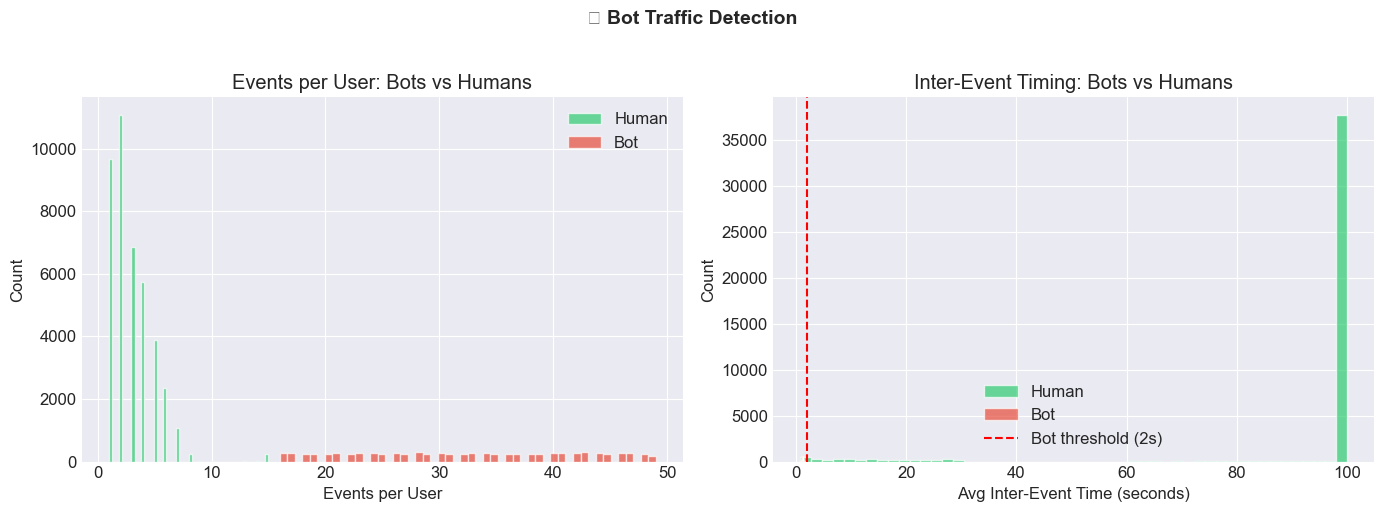

✓ Saved to visuals/bot_detection.png


In [9]:
# Visualize bot vs human event distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Events per user
axes[0].hist(
    user_stats[~user_stats['is_bot']]['total_events'], 
    bins=50, alpha=0.7, label='Human', color='#2ecc71', edgecolor='white'
)
axes[0].hist(
    user_stats[user_stats['is_bot']]['total_events'], 
    bins=50, alpha=0.7, label='Bot', color='#e74c3c', edgecolor='white'
)
axes[0].set_xlabel('Events per User')
axes[0].set_ylabel('Count')
axes[0].set_title('Events per User: Bots vs Humans')
axes[0].legend()

# Avg inter-event time
human_times = user_stats[~user_stats['is_bot']]['avg_inter_event_sec'].clip(upper=100)
bot_times = user_stats[user_stats['is_bot']]['avg_inter_event_sec'].clip(upper=100)
axes[1].hist(human_times, bins=50, alpha=0.7, label='Human', color='#2ecc71', edgecolor='white')
axes[1].hist(bot_times, bins=50, alpha=0.7, label='Bot', color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('Avg Inter-Event Time (seconds)')
axes[1].set_ylabel('Count')
axes[1].set_title('Inter-Event Timing: Bots vs Humans')
axes[1].axvline(x=2.0, color='red', linestyle='--', label='Bot threshold (2s)')
axes[1].legend()

plt.suptitle('🤖 Bot Traffic Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visuals/bot_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to visuals/bot_detection.png")

In [10]:
# Separate bot and human events
bot_user_ids = set(user_stats[user_stats['is_bot']]['user_id'])

events_all = events.copy()  # Keep full dataset for before/after comparison
events_all['is_bot'] = events_all['user_id'].isin(bot_user_ids)

events_human = events[~events['user_id'].isin(bot_user_ids)].copy()

print(f"Events with bots:    {len(events_all):,}")
print(f"Bot events removed:  {events_all['is_bot'].sum():,}")
print(f"Clean human events:  {len(events_human):,}")

Events with bots:    405,002
Bot events removed:  282,166
Clean human events:  122,836


## 5. Deduplicate Events

Keep only the **first occurrence** of each event per user. This prevents inflating funnel numbers with repeated clicks/refreshes.

In [11]:
before_dedup = len(events_human)

# Sort by timestamp and keep first occurrence
events_human = events_human.sort_values('event_timestamp')
events_dedup = events_human.drop_duplicates(
    subset=['user_id', 'event_name'], 
    keep='first'
).copy()

after_dedup = len(events_dedup)
removed = before_dedup - after_dedup

print(f"Before deduplication: {before_dedup:,} events")
print(f"After deduplication:  {after_dedup:,} events")
print(f"Duplicates removed:  {removed:,} ({removed/before_dedup*100:.1f}%)")

Before deduplication: 122,836 events
After deduplication:  97,126 events
Duplicates removed:  25,710 (20.9%)


## 6. Add Funnel Stage Ordering

In [12]:
# Map funnel stages to numeric order
STAGE_ORDER = {
    'website_visit': 1,
    'signup': 2,
    'onboarding_complete': 3,
    'first_project_created': 4,
    'upgrade_to_paid': 5,
    'day_30_active': 6,
}

STAGE_LABELS = {
    'website_visit': 'Website Visit',
    'signup': 'Free Trial Signup',
    'onboarding_complete': 'Onboarding Complete',
    'first_project_created': 'First Project (Aha!)',
    'upgrade_to_paid': 'Upgrade to Paid',
    'day_30_active': '30-Day Retained',
}

events_dedup['stage_order'] = events_dedup['event_name'].map(STAGE_ORDER)
events_dedup['stage_label'] = events_dedup['event_name'].map(STAGE_LABELS)

print("✓ Funnel stage ordering applied")
print("\nEvent distribution (cleaned & deduplicated):")
display(
    events_dedup.groupby(['stage_order', 'stage_label'])
    .agg(users=('user_id', 'nunique'))
    .reset_index()
    .sort_values('stage_order')
)

✓ Funnel stage ordering applied

Event distribution (cleaned & deduplicated):


,stage_order,stage_label,users
0,1,Website Visit,41106
1,2,Free Trial Signup,27101
2,3,Onboarding Complete,14095
3,4,First Project (Aha!),10166
4,5,Upgrade to Paid,2695
5,6,30-Day Retained,1963


## 7. Merge with User Attributes

In [13]:
# Merge events with user demographic data
users = users_raw.copy()

# Only keep human users
users_clean = users[~users['user_id'].isin(bot_user_ids)].copy()

events_final = events_dedup.merge(
    users_clean[['user_id', 'device', 'acquisition_channel', 'country', 'plan_type']],
    on='user_id',
    how='left'
)

print(f"Final dataset: {len(events_final):,} rows × {events_final.shape[1]} columns")
print(f"Unique users: {events_final['user_id'].nunique():,}")
display(events_final.head())

Final dataset: 97,126 rows × 12 columns
Unique users: 41,230


,event_id,user_id,event_name,event_timestamp,session_id,platform,stage_order,stage_label,device,acquisition_channel,country,plan_type
0,evt_c9d8f666eabe,user_512ff2bdc5c3,website_visit,2025-01-01 00:00:00.000000,sess_e73e839e36,Desktop,1,Website Visit,Desktop,Paid Ads,India,Free Trial
1,evt_c00be09f85aa,user_886cf2116970,website_visit,2025-01-01 00:06:00.000000,sess_4a85e69436,Desktop,1,Website Visit,Desktop,Referral,US,Free Trial
2,evt_8160bae69f05,user_10e3a84b7833,website_visit,2025-01-01 00:09:00.000000,sess_d37ca0ae23,Desktop,1,Website Visit,Desktop,Paid Ads,UK,Free Trial
3,evt_11576a32ae6f,user_7756530d0064,website_visit,2025-01-01 00:11:00.000000,sess_bde74cea91,Tablet,1,Website Visit,Tablet,Organic,Canada,Free Trial
4,evt_7f212652c488,user_512ff2bdc5c3,signup,2025-01-01 00:13:51.129030,sess_e73e839e36,Desktop,2,Free Trial Signup,Desktop,Paid Ads,India,Free Trial


## 8. Data Quality Summary

In [14]:
print("=" * 60)
print("  DATA CLEANING SUMMARY")
print("=" * 60)
print(f"""  
  Raw events:              {len(events_raw):,}
  After null removal:      {len(events):,}  (dropped {null_ts_count:,} null timestamps)
  After platform cleanup:  {len(events) - unmapped:,}  (fixed {unmapped} invalid platforms)
  After bot filtering:     {len(events_human):,}  (removed {bot_count:,} bot users / {events_all['is_bot'].sum():,} events)
  After deduplication:     {len(events_dedup):,}  (removed {removed:,} duplicate events)
  Final dataset:           {len(events_final):,} clean events, {events_final['user_id'].nunique():,} users
""")
print("=" * 60)

  DATA CLEANING SUMMARY
  
  Raw events:              407,367
  After null removal:      405,002  (dropped 2,070 null timestamps)
  After platform cleanup:  404,707  (fixed 295 invalid platforms)
  After bot filtering:     122,836  (removed 8,720 bot users / 282,166 events)
  After deduplication:     97,126  (removed 25,710 duplicate events)
  Final dataset:           97,126 clean events, 41,230 users



## 9. Save Cleaned Data

In [15]:
import os
os.makedirs('../data/cleaned', exist_ok=True)
os.makedirs('../visuals', exist_ok=True)

# Save cleaned events
events_final.to_csv('../data/cleaned/clean_events.csv', index=False)
print(f"✓ Saved clean_events.csv ({len(events_final):,} rows)")

# Save cleaned users
users_clean.to_csv('../data/cleaned/clean_users.csv', index=False)
print(f"✓ Saved clean_users.csv ({len(users_clean):,} rows)")

# Save bot flagged data (for before/after comparison in dashboard)
events_all.to_csv('../data/cleaned/events_with_bot_flag.csv', index=False)
print(f"✓ Saved events_with_bot_flag.csv ({len(events_all):,} rows)")

# Save user bot flags
user_stats[['user_id', 'is_bot', 'total_events', 'avg_inter_event_sec']].to_csv(
    '../data/cleaned/user_bot_flags.csv', index=False
)
print(f"✓ Saved user_bot_flags.csv")

✓ Saved clean_events.csv (97,126 rows)
✓ Saved clean_users.csv (41,280 rows)
✓ Saved events_with_bot_flag.csv (405,002 rows)
✓ Saved user_bot_flags.csv
